In [2]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
# from ydata_profiling import ProfileReport
import warnings
warnings.filterwarnings('ignore')
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.decomposition import PCA
import time
import os
np.random.seed(42)

# Set beautiful plotting style
plt.style.use('default')
sns.set_palette("husl")

In [3]:
from notebook2.clustering_utils import (
    # Clustering utilities
    calculate_silhouette_score,
    calculate_elbow_method,
)

from notebook2.visualization_utils import (
    # Visualization utilities
    plot_silhouette_analysis,
    plot_elbow_method,
)

# **Đọc dữ liệu**

In [7]:
%cd D:\ĐÔNG HY\Tai_xuong\Programs\Hoc_code\DL_ON_TANG_DONG_HY\Khoa7_Do_an_tot_nghiep_DS\nhatot_recommender_and_clustering
# cd vào thư mục lưu data

D:\ĐÔNG HY\Tai_xuong\Programs\Hoc_code\DL_ON_TANG_DONG_HY\Khoa7_Do_an_tot_nghiep_DS\nhatot_recommender_and_clustering


In [8]:
# Đọc dữ liệu
if os.path.exists("Data\well_formed_data.csv"):
    df = pd.read_csv("Data\well_formed_data.csv")
    print("Dữ liệu đã được tải thành công!")
    print(df.shape)
else:
    print("Không tìm thấy file dữ liệu. Vui lòng kiểm tra lại đường dẫn và tên file.")

Dữ liệu đã được tải thành công!
(6920, 26)


In [9]:
df.head(3)

,gia_ban,loai_hinh,dien_tich_dat,giay_to_phap_ly,so_phong_ngu,so_phong_ve_sinh,tong_so_tang,tinh_trang_noi_that,dac_diem,chieu_ngang,...,vi_tri_trung_tam,truong_hoc,san_bay,benh_vien,sieu_thi,giao_thong,giai_tri,dia_diem_dac_biet,phuong,gia_m2_tham_khao
0,3.850000e+09,"Nhà ngõ, hẻm",36.0,Đã có sổ,2.0,2.0,2.0,Nội thất đầy đủ,Nhà nở hậu,4.5,...,1,1,1,1,0,0,0,0,Phường Gia Định,140910000.0
1,9.790000e+09,"Nhà ngõ, hẻm",62.0,Chưa xác định,4.0,3.0,3.0,Không rõ,Thông thường,4.0,...,1,0,1,0,0,0,0,0,Phường Bình Lợi Trung,140000000.0
2,7.200000e+09,"Nhà ngõ, hẻm",54.0,Đã có sổ,3.0,2.0,2.0,Hoàn thiện cơ bản,Hẻm xe hơi,7.0,...,1,0,1,0,0,0,0,0,Phường Bình Lợi Trung,151050000.0


In [10]:
df.columns

Index(['gia_ban', 'loai_hinh', 'dien_tich_dat', 'giay_to_phap_ly',
       'so_phong_ngu', 'so_phong_ve_sinh', 'tong_so_tang',
       'tinh_trang_noi_that', 'dac_diem', 'chieu_ngang', 'duong_lon',
       'vi_tri_dat', 'garage', 'san_vuon', 'hai_mat_tien', 'view',
       'vi_tri_trung_tam', 'truong_hoc', 'san_bay', 'benh_vien', 'sieu_thi',
       'giao_thong', 'giai_tri', 'dia_diem_dac_biet', 'phuong',
       'gia_m2_tham_khao'],
      dtype='object')

## **Handle Outliers**

In [11]:
def remove_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.1)
    Q3 = df[col].quantile(0.9)
    IQR = Q3 - Q1
    # Chỉ giữ lại dữ liệu nằm trong "vùng an toàn"
    return df[(df[col] >= Q1 - 1.5 * IQR) & (df[col] <= Q3 + 1.5 * IQR)]

In [12]:
# # Cắt bỏ outliers cho 2 biến dễ gây nhiễu nhất
# df = remove_outliers_iqr(df, 'gia_ban')
# print(f"Số lượng sau khi 'trảm' Outliers: {len(df)} căn nhà")

# **Data Transformation**

In [13]:
df_transformed = df.copy()

In [14]:
df_transformed.columns

Index(['gia_ban', 'loai_hinh', 'dien_tich_dat', 'giay_to_phap_ly',
       'so_phong_ngu', 'so_phong_ve_sinh', 'tong_so_tang',
       'tinh_trang_noi_that', 'dac_diem', 'chieu_ngang', 'duong_lon',
       'vi_tri_dat', 'garage', 'san_vuon', 'hai_mat_tien', 'view',
       'vi_tri_trung_tam', 'truong_hoc', 'san_bay', 'benh_vien', 'sieu_thi',
       'giao_thong', 'giai_tri', 'dia_diem_dac_biet', 'phuong',
       'gia_m2_tham_khao'],
      dtype='object')

## *Log Transform*

In [15]:
'''
PA: Mình cứ lấy log nhỡ cần xài nhưng bên dưới mình cũng ko xài =))
'''

'\nPA: Mình cứ lấy log nhỡ cần xài nhưng bên dưới mình cũng ko xài =))\n'

In [16]:
df_transformed['log_gia_vnd'] = np.log1p(df_transformed['gia_ban'])
df_transformed['log_dien_tich_dat'] = np.log1p(df_transformed['dien_tich_dat'])
df_transformed['log_gia_m2_tham_khao'] = np.log1p(df_transformed['gia_m2_tham_khao'])
df_transformed['log_chieu_ngang'] = np.log1p(df_transformed['chieu_ngang'])

df_transformed['price_m2'] = (df['gia_ban'] / df['dien_tich_dat'])/ 1e6
df_transformed['log_price_m2'] = np.log1p(df_transformed['price_m2'])

## Feature Selection

In [17]:
df_transformed.columns

Index(['gia_ban', 'loai_hinh', 'dien_tich_dat', 'giay_to_phap_ly',
       'so_phong_ngu', 'so_phong_ve_sinh', 'tong_so_tang',
       'tinh_trang_noi_that', 'dac_diem', 'chieu_ngang', 'duong_lon',
       'vi_tri_dat', 'garage', 'san_vuon', 'hai_mat_tien', 'view',
       'vi_tri_trung_tam', 'truong_hoc', 'san_bay', 'benh_vien', 'sieu_thi',
       'giao_thong', 'giai_tri', 'dia_diem_dac_biet', 'phuong',
       'gia_m2_tham_khao', 'log_gia_vnd', 'log_dien_tich_dat',
       'log_gia_m2_tham_khao', 'log_chieu_ngang', 'price_m2', 'log_price_m2'],
      dtype='object')

In [18]:
df_transformed = remove_outliers_iqr(df_transformed, 'price_m2')

In [19]:
df_final = df_transformed[['log_price_m2', 'log_dien_tich_dat']]

In [20]:
'''
PA: đoạn này mình chỉ chọn 1 feature duy nhất để phân cụm là price_m2 của căn nhà. Mình đã thử nhiều features cùng lúc nhưng có vẻ
càng nhiều features thì Kmeans, GMM cho ra kết quả càng rối, sihoutte score càng thấp.
Ý tưởng ở đây là phân cụm giá nhà thành nhiều phân khúc giá khác nhau --> Phù hợp với mua bán nhà đất trong thực tế

'''

'\nPA: đoạn này mình chỉ chọn 1 feature duy nhất để phân cụm là price_m2 của căn nhà. Mình đã thử nhiều features cùng lúc nhưng có vẻ\ncàng nhiều features thì Kmeans, GMM cho ra kết quả càng rối, sihoutte score càng thấp.\nÝ tưởng ở đây là phân cụm giá nhà thành nhiều phân khúc giá khác nhau --> Phù hợp với mua bán nhà đất trong thực tế\n\n'

# Kmeans

## Sử dụng Elbow method




In [21]:
# Step 1: Finding optimal number of clusters using multiple methods
print("\n🎯 Step 1: Finding Optimal Number of Clusters")

# Method 1: Elbow Method
print("\n📈 Method 1: Elbow Method")
elbow_results = calculate_elbow_method(df_final, k_range=range(1, 11))
print(f"Elbow method tested k values: {elbow_results['k_values']}")
print(f"Corresponding inertias: {[f'{x:.0f}' for x in elbow_results['inertias']]}")


🎯 Step 1: Finding Optimal Number of Clusters

📈 Method 1: Elbow Method
Elbow method tested k values: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Corresponding inertias: ['2453', '1288', '973', '764', '633', '528', '468', '416', '379', '345']


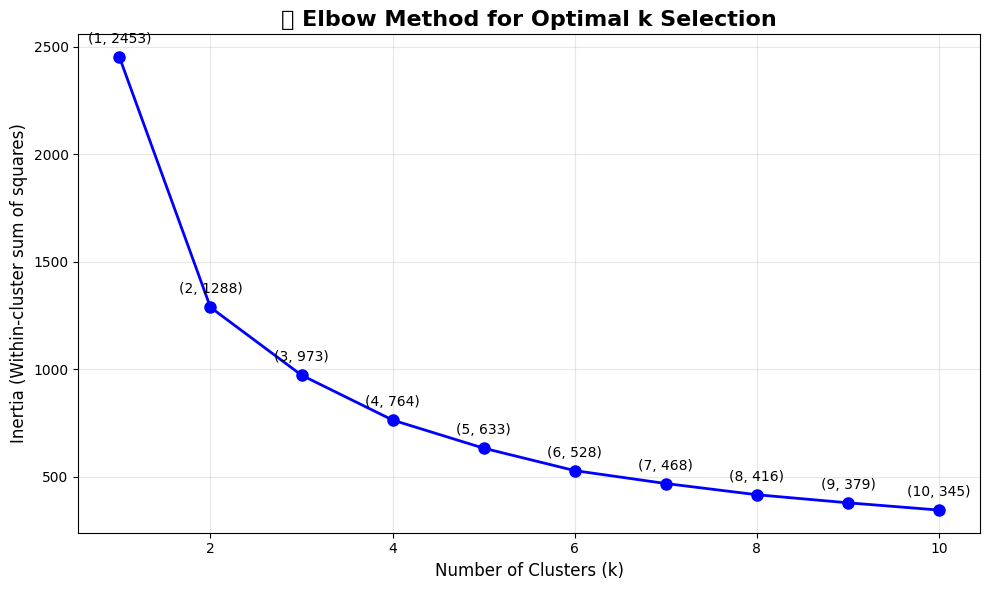

In [22]:
# Visualize elbow method
plot_elbow_method(elbow_results['k_values'], elbow_results['inertias'],
                  title="🔍 Elbow Method for Optimal k Selection")

## Sử dụng Sihoullte score

In [23]:
# Method 2: Silhouette Analysis
print("\n📊 Method 2: KMeans Silhouette Analysis")
silhouette_results = []
k_range = range(2, 8)  # Silhouette requires at least 2 clusters

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(df_final)
    score = calculate_silhouette_score(df_final, labels)
    silhouette_results.append(score)
    print(f"k={k}: Silhouette Score = {score:.4f}")


📊 Method 2: KMeans Silhouette Analysis
k=2: Silhouette Score = 0.4095
k=3: Silhouette Score = 0.3273
k=4: Silhouette Score = 0.3264
k=5: Silhouette Score = 0.3265
k=6: Silhouette Score = 0.3384
k=7: Silhouette Score = 0.3373


In [24]:
# Find optimal k from silhouette analysis
optimal_k_silhouette = list(k_range)[np.argmax(silhouette_results)]
print(f"\n🏆 Optimal k from silhouette analysis: {optimal_k_silhouette}")
print(f"   Best silhouette score: {max(silhouette_results):.4f}")


🏆 Optimal k from silhouette analysis: 2
   Best silhouette score: 0.4095


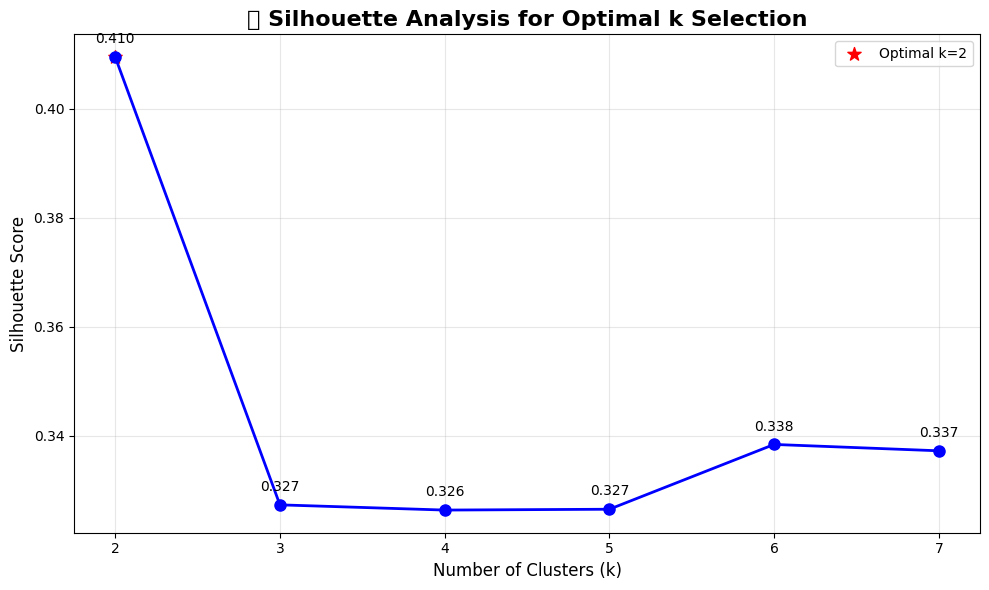

In [25]:
# Visualize silhouette analysis
plt.figure(figsize=(10, 6))
plt.plot(k_range, silhouette_results, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Silhouette Score', fontsize=12)
plt.title('📊 Silhouette Analysis for Optimal k Selection', fontsize=16, fontweight='bold')
plt.grid(True, alpha=0.3)

# Highlight optimal k
max_idx = np.argmax(silhouette_results)
plt.scatter(list(k_range)[max_idx], silhouette_results[max_idx],
            c='red', s=100, marker='*', label=f'Optimal k={optimal_k_silhouette}')
plt.legend()

# Annotate points
for i, (k, score) in enumerate(zip(k_range, silhouette_results)):
    plt.annotate(f'{score:.3f}', (k, score),
                 textcoords="offset points", xytext=(0, 10), ha='center')

plt.tight_layout()
plt.show()

In [26]:
optimal_k_silhouette

2

In [27]:
kmeans = KMeans(n_clusters=optimal_k_silhouette, random_state=42, n_init=10)
km_labels = kmeans.fit_predict(df_final)

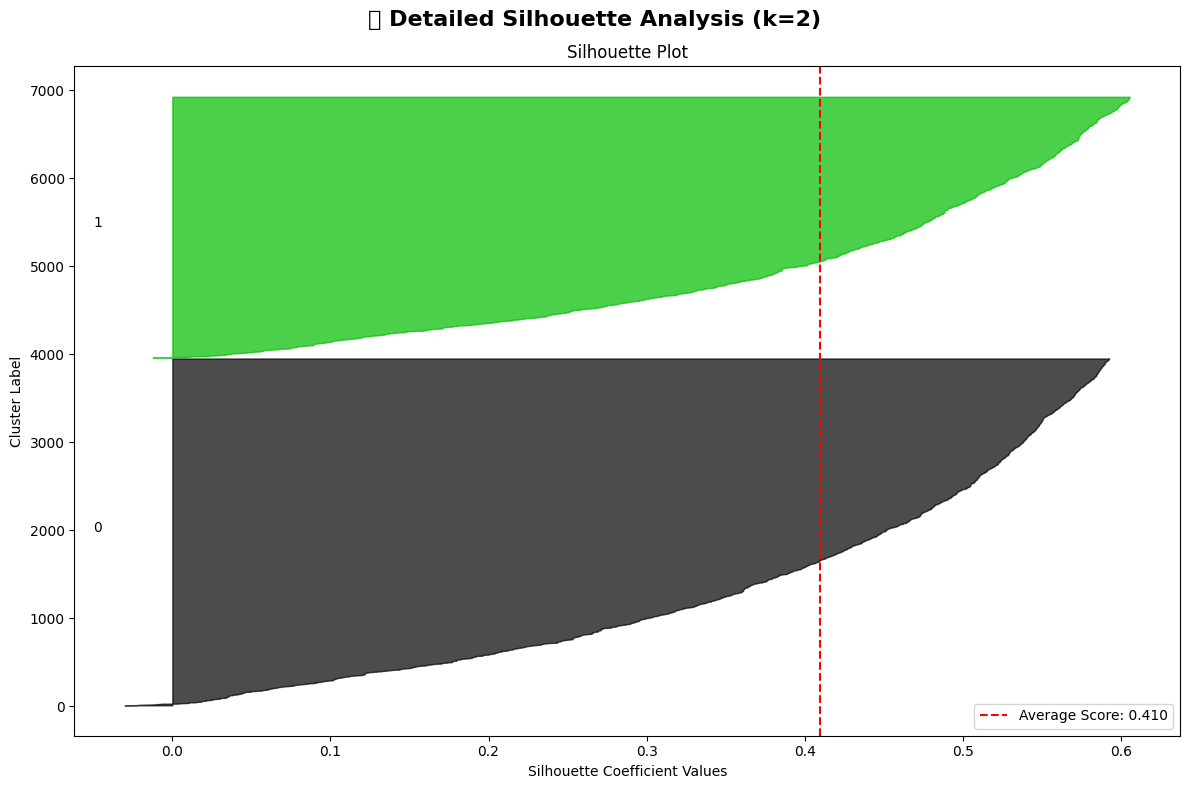

In [28]:
# Create detailed silhouette analysis
plot_silhouette_analysis(df_final.to_numpy(), km_labels,
                         title=f"📊 Detailed Silhouette Analysis (k={optimal_k_silhouette})")

In [29]:
# Save the model
import joblib
joblib.dump(kmeans, "models/kmeans.pkl")
print("KMeans model saved to models/kmeans.pkl")

KMeans model saved to models/kmeans.pkl


In [40]:
'''
PA: Elbow Method và Silhoutte score cho thấy k = 2 là phù hợp, tương tự với GMM bên dưới.
'''

'\nPA: Elbow Method và Silhoutte score cho thấy k = 2 là phù hợp, tương tự với GMM bên dưới.\n'

# GMM

### GMM Silhoette Score

In [41]:
# Step 2: GMM Silhouette Analysis
print("\n📊 Step 2: GMM Silhouette Analysis")

gmm_silhouette_results = []
k_range = range(2, 8)

for k in k_range:
    gmm = GaussianMixture(n_components=k, random_state=42)
    gmm_labels = gmm.fit_predict(df_final)
    score = calculate_silhouette_score(df_final, gmm_labels)
    gmm_silhouette_results.append(score)
    print(f"k={k}: GMM Silhouette Score = {score:.4f}")

optimal_k_gmm_silhouette = list(k_range)[np.argmax(gmm_silhouette_results)]
print(f"\n🏆 Optimal k from GMM silhouette analysis: {optimal_k_gmm_silhouette}")


📊 Step 2: GMM Silhouette Analysis
k=2: GMM Silhouette Score = 0.5930
k=3: GMM Silhouette Score = 0.5430
k=4: GMM Silhouette Score = 0.5499
k=5: GMM Silhouette Score = 0.5316
k=6: GMM Silhouette Score = 0.5351
k=7: GMM Silhouette Score = 0.5275

🏆 Optimal k from GMM silhouette analysis: 2


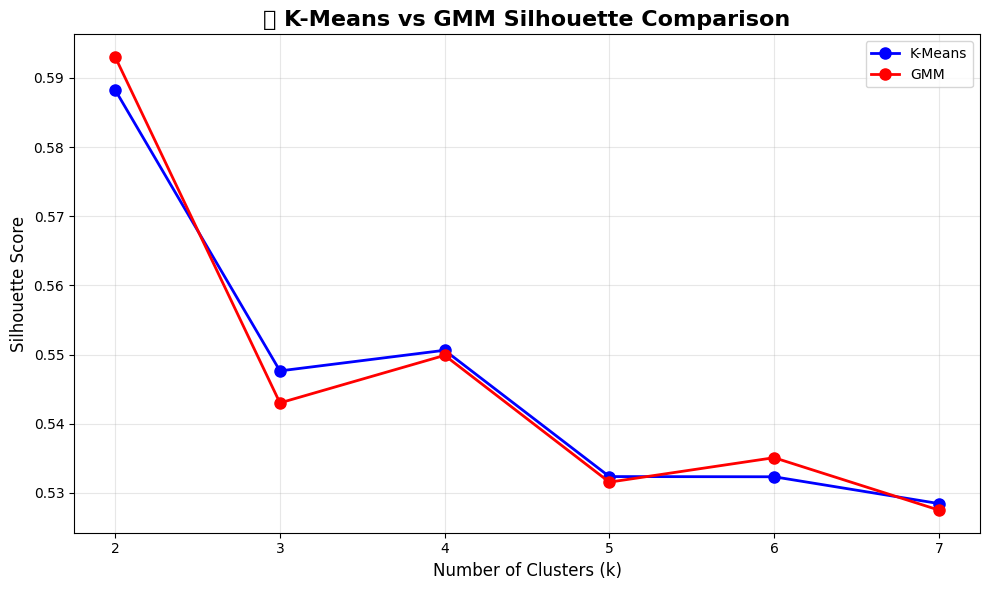

In [42]:
# Compare K-Means vs GMM silhouette scores
plt.figure(figsize=(10, 6))
plt.plot(k_range, silhouette_results, 'bo-', linewidth=2, label='K-Means', markersize=8)
plt.plot(k_range, gmm_silhouette_results, 'ro-', linewidth=2, label='GMM', markersize=8)
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Silhouette Score', fontsize=12)
plt.title('📊 K-Means vs GMM Silhouette Comparison', fontsize=16, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [43]:
# Step 3: Detailed GMM analysis
print(f"\n🔧 Step 3: Detailed GMM Analysis (k={optimal_k_gmm_silhouette})")

# Train GMM with optimal k
gmm_optimal = GaussianMixture(n_components=optimal_k_gmm_silhouette, random_state=42)
gmm_optimal.fit(df_final)

# Get results
labels_gmm = gmm_optimal.predict(df_final)
probabilities_gmm = gmm_optimal.predict_proba(df_final)

print(f"✅ GMM Results:")
print(f"   Converged: {gmm_optimal.converged_}")
print(f"   Number of iterations: {gmm_optimal.n_iter_}")
print(f"   Log-likelihood: {gmm_optimal.score(df_final):.2f}")
print(f"   AIC: {gmm_optimal.aic(df_final):.2f}")
print(f"   BIC: {gmm_optimal.bic(df_final):.2f}")


🔧 Step 3: Detailed GMM Analysis (k=2)
✅ GMM Results:
   Converged: True
   Number of iterations: 6
   Log-likelihood: -5.24
   AIC: 72314.36
   BIC: 72348.56


# Insights

In [44]:
df_transformed['cluster'] = km_labels

In [45]:
mapping = {
    0: "trung - cao cấp",
    1: "thấp - trung cấp"
}
df_transformed['cluster'] = df_transformed['cluster'].map(mapping)

In [46]:
'''
PA: Có thể thấy phân khúc thấp - trung bình là tầm dưới 160 triệu/m2, còn phân khúc trung - cao cấp là trên 160 triệu/m2
'''

'\nPA: Có thể thấy phân khúc thấp - trung bình là tầm dưới 160 triệu/m2, còn phân khúc trung - cao cấp là trên 160 triệu/m2\n'

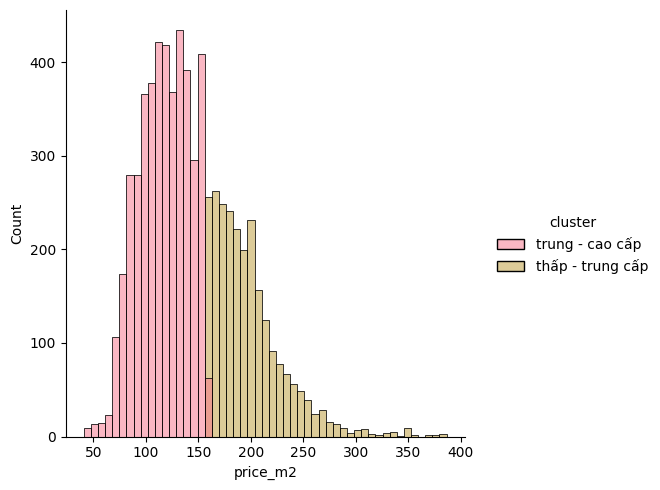

In [47]:
sns.displot(data = df_transformed, x = 'price_m2', hue = 'cluster')
plt.show()

In [48]:
df_transformed.columns

Index(['gia_ban', 'loai_hinh', 'dien_tich_dat', 'giay_to_phap_ly',
       'so_phong_ngu', 'so_phong_ve_sinh', 'tong_so_tang',
       'tinh_trang_noi_that', 'dac_diem', 'chieu_ngang', 'duong_lon',
       'vi_tri_dat', 'garage', 'san_vuon', 'hai_mat_tien', 'view',
       'vi_tri_trung_tam', 'truong_hoc', 'san_bay', 'benh_vien', 'sieu_thi',
       'giao_thong', 'giai_tri', 'dia_diem_dac_biet', 'phuong',
       'gia_m2_tham_khao', 'log_gia_vnd', 'log_dien_tich_dat',
       'log_gia_m2_tham_khao', 'log_chieu_ngang', 'price_m2', 'log_price_m2',
       'cluster'],
      dtype='object')

In [49]:
'''
PA: Dưới đây là một số kết quả thống kê của 2 cluster
Giá trị trong các bảng dưới đây chỉ ra % số nhà chứa thuộc tính/tổng số nhà thuộc cluster đó --> Phản ánh sự khác biệt giữa 2 clusters
'''

'\nPA: Dưới đây là một số kết quả thống kê của 2 cluster\nGiá trị trong các bảng dưới đây chỉ ra % số nhà chứa thuộc tính/tổng số nhà thuộc cluster đó --> Phản ánh sự khác biệt giữa 2 clusters\n'

In [50]:
features = ['duong_lon',
       'vi_tri_dat', 'garage', 'san_vuon', 'hai_mat_tien', 'view',
       'vi_tri_trung_tam', 'truong_hoc', 'san_bay', 'benh_vien', 'sieu_thi',
       'giao_thong', 'giai_tri', 'dia_diem_dac_biet']

df_transformed.groupby('cluster')[features].mean()

,duong_lon,vi_tri_dat,garage,san_vuon,hai_mat_tien,view,vi_tri_trung_tam,truong_hoc,san_bay,benh_vien,sieu_thi,giao_thong,giai_tri,dia_diem_dac_biet
cluster,,,,,,,,,,,,,,
thấp - trung cấp,0.388957,0.104750,0.046691,0.486805,0.041413,0.017052,0.418189,0.272838,0.149005,0.111246,0.320341,0.011368,0.083638,0.020300
trung - cao cấp,0.281180,0.080369,0.023863,0.352544,0.020711,0.011481,0.288609,0.285457,0.106934,0.082395,0.365826,0.014858,0.084196,0.015308


In [51]:
pivot_loai = pd.crosstab(
    df_transformed['cluster'],
    df_transformed['loai_hinh'],
    normalize='index'
).round(3)

pivot_loai

loai_hinh,"Nhà mặt phố, mặt tiền","Nhà ngõ, hẻm"
cluster,,
thấp - trung cấp,0.102,0.898
trung - cao cấp,0.040,0.960


In [52]:
pivot_noi_that = pd.crosstab(
    df_transformed['cluster'],
    df_transformed['tinh_trang_noi_that'],
    normalize='index'
).round(3)

pivot_noi_that

tinh_trang_noi_that,Bàn giao thô,Hoàn thiện cơ bản,Không rõ,Nội thất cao cấp,Nội thất đầy đủ
cluster,,,,,
thấp - trung cấp,0.009,0.066,0.422,0.269,0.234
trung - cao cấp,0.011,0.116,0.450,0.193,0.230


In [53]:
'''
PA: bảng dưới đây chỉ ra các giá trị trung bình của các feature số khác nhau giữa 2 clusters

Có gì mình sẽ trực quan hóa thêm mấy cái này cho dễ nhìn hơn.
'''

'\nPA: bảng dưới đây chỉ ra các giá trị trung bình của các feature số khác nhau giữa 2 clusters\n\nCó gì mình sẽ trực quan hóa thêm mấy cái này cho dễ nhìn hơn.\n'

In [54]:
df_transformed.groupby('cluster')[[
    'price_m2',
    'dien_tich_dat',
    'chieu_ngang',
    'so_phong_ngu',
    'so_phong_ve_sinh',
    'tong_so_tang'
]].mean()

,price_m2,dien_tich_dat,chieu_ngang,so_phong_ngu,so_phong_ve_sinh,tong_so_tang
cluster,,,,,,
thấp - trung cấp,197.595425,44.146913,4.278844,3.736500,3.496549,3.366017
trung - cao cấp,117.282922,57.742064,5.469041,3.293787,2.989644,2.697771


In [55]:
def plot_cluster_results(df, features, cluster_col, title_suffix=""):
    """
    Optimized visualization function with PCA support and centroid highlighting.
    """
    import matplotlib.pyplot as plt
    import seaborn as sns
    from sklearn.decomposition import PCA

    n_features = len(features)
    plot_df = df.copy()

    # Case 1: More than 3 features - Use PCA
    if n_features > 3:
        pca = PCA(n_components=2)
        pca_data = pca.fit_transform(StandardScaler().fit_transform(df[features]))
        plot_df['PCA1'] = pca_data[:, 0]
        plot_df['PCA2'] = pca_data[:, 1]
        vis_features = ['PCA1', 'PCA2']
        title = f"PCA Cluster Visualization (Reduced from {n_features} features)"
    else:
        vis_features = features
        title = f"{len(features)}D Clustering Visualization {title_suffix}"

    # Plotting
    if len(vis_features) == 2:
        plt.figure(figsize=(12, 7))
        sns.scatterplot(data=plot_df, x=vis_features[0], y=vis_features[1],
                        hue=cluster_col, palette='husl', alpha=0.5, s=40, edgecolor='w')

        # Highlight Centroids
        centroids = plot_df.groupby(cluster_col)[vis_features].mean()
        plt.scatter(centroids.iloc[:, 0], centroids.iloc[:, 1],
                    marker='X', s=200, c='black', label='Centroids', edgecolors='white')

        plt.title(title, fontsize=14, fontweight='bold')
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()
        plt.show()

    elif len(vis_features) == 3:
        fig = plt.figure(figsize=(12, 8))
        ax = fig.add_subplot(111, projection='3d')

        clusters = plot_df[cluster_col].unique()
        colors = sns.color_palette('husl', len(clusters))

        for i, cluster in enumerate(clusters):
            subset = plot_df[plot_df[cluster_col] == cluster]
            ax.scatter(subset[vis_features[0]], subset[vis_features[1]], subset[vis_features[2]],
                       label=cluster, s=30, alpha=0.4, color=colors[i])

        ax.set_xlabel(vis_features[0])
        ax.set_ylabel(vis_features[1])
        ax.set_zlabel(vis_features[2])
        plt.title(title, fontsize=14, fontweight='bold')
        plt.legend()
        plt.tight_layout()
        plt.show()


--------------------Generating 2D Interactive Cluster Map...--------------------



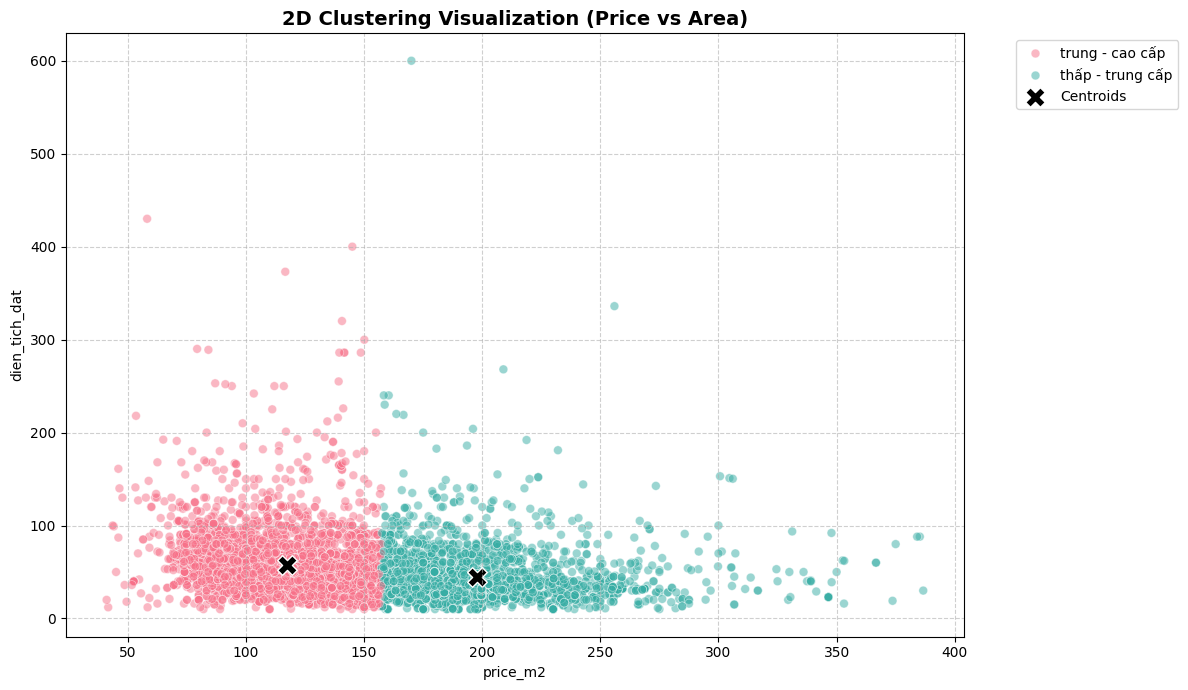


--------------------Generating 3D Interactive Cluster Space...--------------------



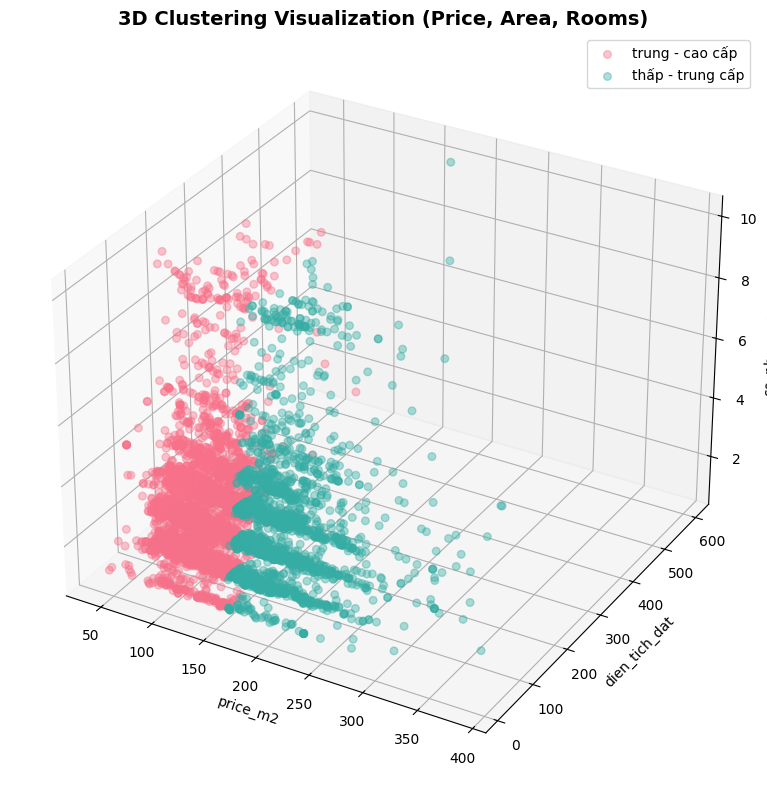

In [56]:
# Optimized Execution Cell for Presentation
# 1. Visualize 2D Clusters (Price vs Area) with interactive Plotly
print("\n" + "-"*20 + "Generating 2D Interactive Cluster Map..." + "-"*20 + "\n")
plot_cluster_results(df_transformed, ['price_m2', 'dien_tich_dat'],
                     'cluster', "(Price vs Area)")

# 2. Visualize 3D Clusters (Price, Area, and Rooms) with interactive Plotly
print("\n" + "-"*20 + "Generating 3D Interactive Cluster Space..." + "-"*20 + "\n")
plot_cluster_results(df_transformed, ['price_m2', 'dien_tich_dat', 'so_phong_ngu'],
                     'cluster', "(Price, Area, Rooms)")

# ====